In [1]:
import numpy as np
import pandas as pd

def aggregate_de_results(
    df,
    group_col="symbol",
    strata_col="level_0",
    lfc_col="log2FoldChange",
    se_col="lfcSE",
    basemean_col="baseMean",
):
    """
    Aggregate DE results across strata (e.g. level_0) for each gene/symbol
    using empirical Bayes-style inverse-variance weighting.

    Returns:
        DataFrame with:
            symbol
            log2FoldChange   # EB pooled estimate
            lfcSE            # pooled SE
            baseMean         # mean baseMean across strata
            n_strata
    """

    def _aggregate_group(g):
        # remove invalid rows
        g = g[
            np.isfinite(g[lfc_col]) &
            np.isfinite(g[se_col]) &
            (g[se_col] > 0)
        ].copy()

        if len(g) == 0:
            return pd.Series({
                "log2FoldChange": np.nan,
                "lfcSE": np.nan,
                "baseMean": np.nan,
                "n_strata": 0,
            })

        # observed effects + variances
        y = g[lfc_col].values
        v = g[se_col].values ** 2

        # ---- empirical Bayes random-effects shrinkage ----
        # DerSimonian-Laird estimate for between-study variance tau^2

        w_fixed = 1 / v
        mu_fixed = np.sum(w_fixed * y) / np.sum(w_fixed)

        Q = np.sum(w_fixed * (y - mu_fixed) ** 2)
        df_Q = len(y) - 1

        C = np.sum(w_fixed) - (np.sum(w_fixed**2) / np.sum(w_fixed))

        tau2 = max(0, (Q - df_Q) / C) if C > 0 else 0

        # EB/random-effects weights
        w = 1 / (v + tau2)

        mu = np.sum(w * y) / np.sum(w)

        # pooled standard error
        se = np.sqrt(1 / np.sum(w))

        return pd.Series({
            "log2FoldChange": mu,
            "lfcSE": se,
            "baseMean": g[basemean_col].mean(),
            "n_strata": len(g),
        })

    out = (
        df.groupby(group_col, observed=True)
        .apply(_aggregate_group)
        .reset_index()
    )

    return out

In [2]:
from tqdm import tqdm
import meta_analysis
from meta_analysis.go import GeneOntologyLibraries
from meta_analysis.ot import UnbalancedSinkhorn, IterativeProportionalFitting
from meta_analysis.meta import MetaAnalysis

/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
GO_LIBRARIES = {
    "GO_BP": "GO_Biological_Process_2025",
    "GO_MF": "GO_Molecular_Function_2025",
    "GO_CC": "GO_Cellular_Component_2025",
    "Reactome": "Reactome_Pathways_2024",
    "SynGO": "SynGO_2024",
    "WikiPathways": "WikiPathways_2024_Human",
    "LINCS_Chem_Pert": "LINCS_L1000_Chem_Pert_Consensus_Sigs",
    "LINCS_CRISPR": "LINCS_L1000_CRISPR_KO_Consensus_Sigs"
}

GO_TERMS = {
    k: GeneOntologyLibraries().pull_assignment_matrix(v)
    for k, v in tqdm(GO_LIBRARIES.items())
}

100%|██████████| 8/8 [03:14<00:00, 24.32s/it]


In [24]:
grey_matter_regions = [
    'Gyrus Frontalis Medius',
    'Insula',
    'Cerebellum GM',
    'Gyrus Temporalis Medius',
    'Gyrus Parietalis',
    'Anterior Cingulate Cortex',
    'Posterior Cingulate Cortex',
    'Occipital Cortex ',
    'Prefrontal Cortex '
]

white_matter_regions = [
    'Frontal WM',
    'Cerebellum WM',
    'Temporal WM',
    'Corpus Callosum',
    'Parietal WM',
    'Occipital WM'
]

In [120]:
import pathlib
import pandas as pd

output_path = pathlib.Path("/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/output/white-matter")
cell_type_libraries = pathlib.Path("/home/jhaberbe/Projects/Personal/MAY2026/cell-deconvolution/output/")

output_path.mkdir(parents=True, exist_ok=True)

for go_name, go_matrix in GO_TERMS.items():

    go_dir = output_path / go_name
    go_dir.mkdir(parents=True, exist_ok=True)

    for ct_path in cell_type_libraries.glob("*/"):

        ct_dir = go_dir / ct_path.stem
        ct_dir.mkdir(parents=True, exist_ok=True)

        df = pd.concat({
            f.stem: pd.read_csv(f, index_col=0)
                    .drop_duplicates(subset=["symbol"])
                    .set_index("symbol")
            for f in ct_path.glob("*.csv")
        }).reset_index().query("level_0 in @white_matter_regions")

        df = aggregate_de_results(df).set_index("symbol")

        GO_TO_USE = go_name
        GO = go_matrix

        genes_available = df.index.intersection(GO.index)
        go_terms_available = GO.columns[GO.loc[genes_available].sum(axis=0).gt(0)]

        df = df.loc[genes_available]

        balanced_matrix = UnbalancedSinkhorn().get_balanced_matrix(
            GO.loc[genes_available, go_terms_available],
            tolerance=1e-12
        )

        table = pd.DataFrame(
            MetaAnalysis().generate_meta_estimate(
                df.loc[genes_available],
                balanced_matrix.loc[genes_available, go_terms_available]
            )
        )

        table.to_csv(ct_dir / f"{go_name}_{ct_path.stem}.csv")
        balanced_matrix.to_csv(ct_dir / f"{go_name}_{ct_path.stem}_balanced.csv")
        df.to_csv(ct_dir / f"{go_name}_{ct_path.stem}_deseq.csv")

Unbalanced Sinkhorn:   2%|▏         | 22/1000 [00:03<02:52,  5.67it/s]


In [148]:
import pandas as pd

GO_TO_USE = "GO_MF"
cell_type = "oligodendrocyte"

output_path = pathlib.Path(
    f"/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/output/white-matter/{GO_TO_USE}/{cell_type}"
)

table = pd.read_csv(output_path / f"{GO_TO_USE}_{cell_type}.csv", index_col=0)
df = pd.read_csv(output_path / f"{GO_TO_USE}_{cell_type}_deseq.csv", index_col=0)
balanced_matrix = pd.read_csv(output_path / f"{GO_TO_USE}_{cell_type}_balanced.csv", index_col=0)

In [149]:
table["expected_change"] = (table["weights"] * np.pow(2, table["shrunken_estimate"])) - table["weights"]

In [150]:
import plotly.express as px

table["symbol"] = table.index

volcano_plot(
    table,
    lfc_col="expected_change",
    pval_col="log10p_eb",
    gene_col=None,
    size_col="n_eff",
    lfc_thresh=50,
    pval_thresh=-np.log10(0.05 / table.shape[0]),
    x_label="Log2 Fold Change",
    y_label="-log10(p-value)",
    title="Volcano Plot",
    up_color="#d62728",      # red
    down_color="#1f77b4",    # blue
    ns_color="#bdbdbd",      # grey
    width=1000,
    height=750,
    size_max=40,
)

In [151]:
table.sort_values(by="log10p_eb").tail(20)

,weights,n_eff,naive_estimate,naive_standard_error,shrunken_estimate,shrunken_se,z_naive,z_eb,p_naive,p_eb,log10p_naive,log10p_eb,B,full_dataset_mean,full_dataset_standard_error,expected_change,symbol
G Protein-Coupled Receptor Binding (GO:0001664),1697.937658,7.491079,-0.137515,0.024268,-0.137155,0.024236,5.666454,5.659242,1.457829e-08,1.520434e-08,7.836293,7.818032,0.997308,-0.003767,0.218226,-153.985187,G Protein-Coupled Receptor Binding (GO:0001664)
Neutral L-amino Acid:Sodium Symporter Activity (GO:0005295),113.302886,1.701619,-0.542427,0.093946,-0.521488,0.092102,5.773797,5.662056,7.750489e-09,1.495700e-08,8.110671,7.825156,0.961128,-0.003767,0.218226,-34.370101,Neutral L-amino Acid:Sodium Symporter Activity...
poly(G) Binding (GO:0034046),637.016260,2.418012,0.226444,0.039621,0.224800,0.039479,5.715271,5.694143,1.095292e-08,1.239928e-08,7.960470,7.906603,0.992858,-0.003767,0.218226,107.410744,poly(G) Binding (GO:0034046)
Transferrin Receptor Binding (GO:1990459),3214.104281,1.098270,-0.101665,0.017639,-0.101525,0.017626,5.763680,5.759880,8.229956e-09,8.417393e-09,8.084602,8.074822,0.998576,-0.003767,0.218226,-218.407737,Transferrin Receptor Binding (GO:1990459)
"Hydrolase Activity, Acting on Carbon-Nitrogen (But Not Peptide) Bonds, in Cyclic Amides (GO:0016812)",186.302592,2.002175,-0.438282,0.073264,-0.427851,0.072379,5.982236,5.911245,2.200944e-09,3.395319e-09,8.657391,8.469119,0.975994,-0.003767,0.218226,-47.811206,"Hydrolase Activity, Acting on Carbon-Nitrogen ..."
RAGE Receptor Binding (GO:0050786),567.022097,1.171030,0.251543,0.041995,0.249496,0.041827,5.989797,5.965017,2.101030e-09,2.446079e-09,8.677568,8.611529,0.991983,-0.003767,0.218226,107.049173,RAGE Receptor Binding (GO:0050786)
mRNA 3'-UTR Binding (GO:0003730),2004.477028,14.230252,0.133767,0.022336,0.133453,0.022310,5.988937,5.981718,2.112171e-09,2.207965e-09,8.675271,8.656008,0.997719,-0.003767,0.218226,194.266376,mRNA 3'-UTR Binding (GO:0003730)
Phosphoric Diester Hydrolase Activity (GO:0008081),1118.319628,1.553582,-0.179290,0.029903,-0.178574,0.029842,5.995690,5.983959,2.026228e-09,2.177778e-09,8.693312,8.661986,0.995919,-0.003767,0.218226,-130.199189,Phosphoric Diester Hydrolase Activity (GO:0008...
Dihydropyrimidinase Activity (GO:0004157),180.064124,1.871591,-0.456866,0.074522,-0.445621,0.073592,6.130589,6.055309,8.755453e-10,1.401481e-09,9.057721,8.853413,0.975183,-0.003767,0.218226,-47.848777,Dihydropyrimidinase Activity (GO:0004157)
Exonuclease Activity (GO:0004527),1070.094377,1.428015,-0.192474,0.030570,-0.191670,0.030504,6.296271,6.283360,3.048906e-10,3.313326e-10,9.515856,9.479736,0.995736,-0.003767,0.218226,-133.128417,Exonuclease Activity (GO:0004527)


/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/meta_analysis/pl.py:206: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  


(            gene      L2FC        SE  lower_ci  upper_ci  pct_contribution
 MVP          MVP -0.053892  0.082631 -0.215849  0.108065          0.005511
 SMG5        SMG5  0.206647  0.082496  0.044954  0.368339          0.005841
 JUP          JUP  0.014491  0.105745 -0.192770  0.221752          0.006244
 JAK1        JAK1  0.134116  0.075239 -0.013352  0.281583          0.006649
 KIF3A      KIF3A -0.035608  0.075243 -0.183084  0.111868          0.006654
 MTMR4      MTMR4 -0.303034  0.097607 -0.494343 -0.111724          0.007514
 IGBP1      IGBP1 -0.006823  0.076350 -0.156470  0.142824          0.007743
 AKAP11    AKAP11  0.182278  0.085044  0.015592  0.348963          0.007852
 PPP1R3F  PPP1R3F  0.195808  0.110406 -0.020587  0.412204          0.008407
 IQGAP1    IQGAP1 -0.234111  0.080593 -0.392073 -0.076149          0.008443
 SLTM        SLTM -0.019998  0.096015 -0.208187  0.168192          0.008565
 PPME1      PPME1 -0.322628  0.113032 -0.544172 -0.101085          0.008624
 ANAPC5    A

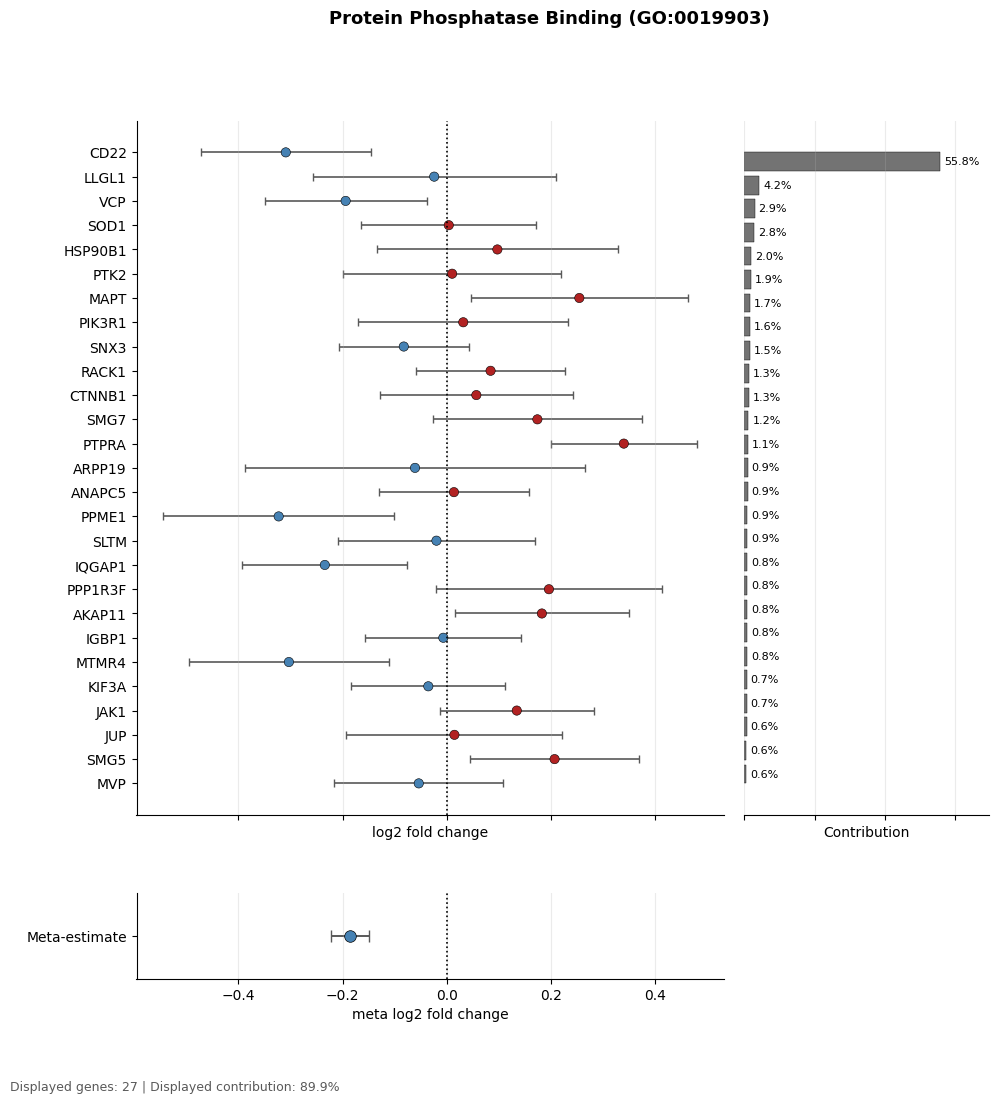

In [153]:
from meta_analysis.pl import ForestPlotter

###### SOMETHING HORRIBLE IS GOING ON HERE
ForestPlotter(df, (balanced_matrix.T * df["baseMean"]).T, table) \
    .plot_term("Protein Phosphatase Binding (GO:0019903)", cutoff=.9)

In [145]:
from scipy.stats import norm
df["p"] = norm.sf(np.abs(df["log2FoldChange"] / df["lfcSE"])) * 2
df["log10p"] = -np.log10(df["p"])

In [147]:
df["expected_change"] = (np.pow(2, df["log2FoldChange"]) * df["baseMean"]) - df["baseMean"]

volcano_plot(
    df,
    lfc_col="expected_change",
    pval_col="log10p",
    gene_col=None,
    size_col="baseMean",
    lfc_thresh=100,
    pval_thresh=-np.log10(0.05 / df.shape[0]),
    x_label="Expected Change",
    y_label="-log10(p-value)",
    title="Volcano Plot",
    up_color="#d62728",      # red
    down_color="#1f77b4",    # blue
    ns_color="#bdbdbd",      # grey
    width=1000,
    height=750,
    size_max=40,
)